# Experiment 05: Simulation of Handover Between Two Cellular Cells

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 3 handoff mechanism; William C. Y. Lee handoff discussion (signal-strength and C/I decision parameters).

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To simulate the handover of a moving mobile from one serving cell to another using received signal strength and a hysteresis margin.

## Objectives

- Understand serving cell, target cell, handover threshold, and hysteresis.
- Model received signal strength from two base stations.
- Simulate a mobile moving from Cell 1 toward Cell 2.
- Detect the handover point.
- Visualize RSS and the serving-cell decision.

## Theory

**Handover (handoff)** is the transfer of an active connection from one cell/base station to another as the mobile moves or radio conditions change.

The course/reference material discusses signal-strength-based handoff as one practical decision method. A simple model is

$$
P_r(d)=P_r(d_0)-10n\log_{10}\left(\frac{d}{d_0}\right)
$$

where $n$ is the path-loss exponent and $d_0$ is the reference distance. This notebook uses $d_0 = 1$ m, so $P_r(d_0)$ is the received level at 1 m.

If the mobile is currently served by BS1, a simple handover rule is

$$
RSS_2 > RSS_1 + H
$$

together with a weak-serving-signal condition

$$
RSS_1 < T_H
$$

where:

- $H$ = hysteresis margin,
- $T_H$ = handover threshold.

**Hysteresis** prevents repeated back-and-forth handovers near the cell boundary (the ping-pong effect).

This notebook uses a deterministic log-distance model so that the handover mechanism is easy to understand and reproduce.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Base station positions on a straight road
bs1_position_m = 0.0
bs2_position_m = 1000.0

# Propagation / handover settings
rss_at_1m_dbm = -30.0
path_loss_exponent = 3.0
hysteresis_db = 3.0
handover_threshold_dbm = -105.0

mobile_positions_m = np.linspace(1, 999, 500)

def received_signal_dbm(distance_m, rss_ref_dbm=-30.0, n=3.0):
    distance_m = np.maximum(distance_m, 1.0)
    return rss_ref_dbm - 10 * n * np.log10(distance_m)

rss1 = received_signal_dbm(
    np.abs(mobile_positions_m - bs1_position_m),
    rss_at_1m_dbm,
    path_loss_exponent
)
rss2 = received_signal_dbm(
    np.abs(mobile_positions_m - bs2_position_m),
    rss_at_1m_dbm,
    path_loss_exponent
)

In [2]:
serving_cell = []
current = 1
handover_position_m = None

for x, r1, r2 in zip(mobile_positions_m, rss1, rss2):
    if current == 1:
        if (r2 > r1 + hysteresis_db) and (r1 < handover_threshold_dbm):
            current = 2
            if handover_position_m is None:
                handover_position_m = x
    else:
        if (r1 > r2 + hysteresis_db) and (r2 < handover_threshold_dbm):
            current = 1
    serving_cell.append(current)

serving_cell = np.array(serving_cell)

print(f"Hysteresis margin   : {hysteresis_db:.1f} dB")
print(f"Handover threshold  : {handover_threshold_dbm:.1f} dBm")
print(f"First handover point: {handover_position_m:.1f} m")

Hysteresis margin   : 3.0 dB
Handover threshold  : -105.0 dBm
First handover point: 559.0 m


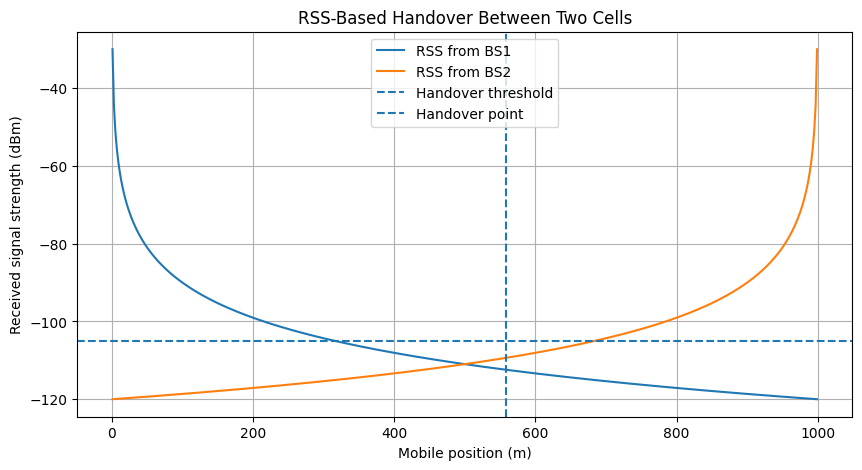

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(mobile_positions_m, rss1, label="RSS from BS1")
plt.plot(mobile_positions_m, rss2, label="RSS from BS2")
plt.axhline(handover_threshold_dbm, linestyle="--", label="Handover threshold")
if handover_position_m is not None:
    plt.axvline(handover_position_m, linestyle="--", label="Handover point")
plt.xlabel("Mobile position (m)")
plt.ylabel("Received signal strength (dBm)")
plt.title("RSS-Based Handover Between Two Cells")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Near BS1, $RSS_1$ is stronger. As the mobile approaches BS2, $RSS_2$ rises while $RSS_1$ falls. The handover is delayed until the target is sufficiently stronger **and** the serving signal is below the selected threshold.

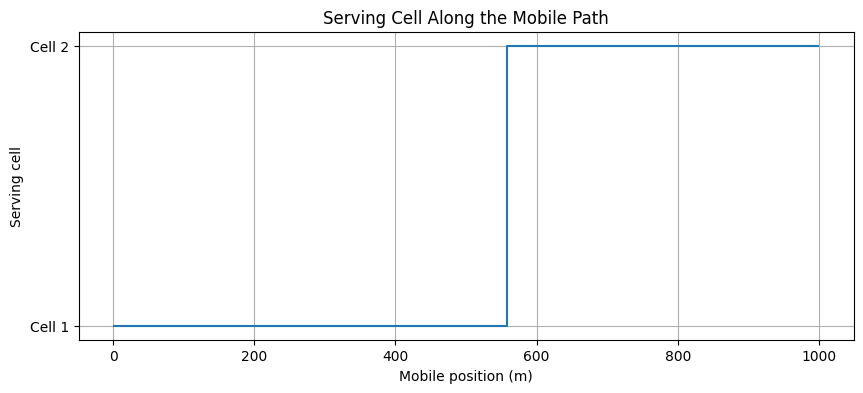

In [4]:
plt.figure(figsize=(10, 4))
plt.step(mobile_positions_m, serving_cell, where="mid")
plt.xlabel("Mobile position (m)")
plt.ylabel("Serving cell")
plt.yticks([1, 2], ["Cell 1", "Cell 2"])
plt.title("Serving Cell Along the Mobile Path")
plt.grid(True)
plt.show()

## Result and Discussion

The simulation produces a single stable handover from Cell 1 to Cell 2. The hysteresis margin prevents a decision based on a very small RSS difference, and the threshold prevents an unnecessarily early handover.

In a real network, decisions can also use interference, quality measurements, load, timing, and technology-specific measurements. This experiment intentionally isolates the basic handover idea.

## Conclusion

Handover between two cells was simulated successfully using RSS, threshold, and hysteresis.

## Viva Questions and Short Answers

1. **Why is handover necessary?**  
   To maintain an active connection as a user moves between coverage areas.

2. **What is hysteresis in handover?**  
   A margin requiring the target signal to be sufficiently stronger before handover.

3. **What is ping-pong handover?**  
   Rapid repeated handovers between neighboring cells.

4. **What is a serving cell?**  
   The cell currently carrying the mobile's connection.

5. **Can handover use parameters other than RSS?**  
   Yes. Signal quality, interference, load, and technology-specific measurements may also be used.